# OpenEO endpoint in Examind - External STAC and Custom Processes

By Quentin BIALOTA (Geomatys)

Contact : quentin.bialota@geomatys.com

---

In this tutorial we will use the python client to create and execute openEO processes on Examind.

---

**Prerequisites :**
- Have an examind (via docker) running on your machine
- Have an examind running somewhere (if local, web ui : http://localhost/8080/examind [login: admin / password: admin])
- In examind, have created a WCS (in Web Services page) named `test`
- In examind, have created a WPS (in Web Services page) named `test`
  - You need to enable Versions `1.0.0` **AND** `2.0.0`
  - Select `Allow deploy process on service`, `Only authenticated user can deploy service`, `Only authenticated user can execute process` as you want for your openEO instance
- In the docker compose, have added the following environment variables to the examind service :
  ```yml
    environment:
      EXAMIND_ENABLE_BASIC_AUTH: "true" # To be able to authenticate on openEO endpoints
      EXAMIND_ENABLE_PARAM_TOKEN: "true" # To be able to authenticate on openEO endpoints

      # Configure your openEO service to use an external STAC
      EXA_OPENEO_EXTERNAL_STAC_PER_WPS_SERVICE: "[test,<your_stac_endpoint>]"
      # Configure your openEO service to use a custom process with your external STAC
      EXA_OPENEO_EXTERNAL_STAC_CUSTOM_PROCESS_PER_WPS_SERVICE: "[test,<your_custom_process_id>]"
  ```
  - Change `<your_stac_endpoint>` by the external stac url you want to use (ex `https://stac-pg-api.ifremer.fr`)
  - Change `<your_custom_process_id>` by your custom process id deployed (ex in this tuto `STACDownloader` (see below why))
- Deploy on the `test` WPS service your custom process (follow the guide in the [cwl_stac_downloader.ipynb](../ExternalProcesses/cwl_stac_downloader.ipynb))
  **In this example we use a custom STACDownloader (using `stac_downloader_ifremer.py` in the CWL process)**

In [42]:
import openeo as eo
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from io import BytesIO
from matplotlib.colors import LinearSegmentedColormap

SERVER_URL = "http://localhost:8080/examind/WS/openeo/WCS"
LOGIN = "admin"
PASSWORD = "admin"

### 1 - Connection to the server

In [43]:
connection = eo.connect(SERVER_URL)

print("Authenticate with Basic authentication")
connection.authenticate_basic(LOGIN, PASSWORD)

print(connection)

Authenticate with Basic authentication
<Connection to 'http://localhost:8080/examind/WS/openeo/WCS/' with BasicBearerAuth>


In [44]:
connection.describe_collection("sea_surface_subskin_temperature")

{'stac_version': '1.0.0',
 'stac_extensions': [],
 'type': 'Collection',
 'keywords': [],
 'cube:dimensions': {'t': {'extent': ['1970-01-01T00:00:00',
    '1970-01-01T00:00:00'],
   'values': ['1970-01-01T00:00:00'],
   'step': None,
   'type': 'temporal'},
  'x': {'axis': 'x',
   'extent': [-46.784334922426865, -18.032071094571698],
   'values': [],
   'step': None,
   'unit': 'degree',
   'reference_system': '84',
   'type': 'spatial'},
  'y': {'axis': 'y',
   'extent': [-24.20417617131575, -8.180588839108394],
   'values': [],
   'step': None,
   'unit': 'degree',
   'reference_system': '84',
   'type': 'spatial'},
  'bands': {'values': ['0'], 'type': 'bands'}},
 'deprecated': False,
 'license': 'no licence specified',
 'summaries': {'bands': [{'unit': 'K',
    'name': '0',
    'description': 'sea_surface_temperature'}]},
 'providers': None,
 'id': 'sea_surface_subskin_temperature',
 'title': 'sea_surface_subskin_temperature',
 'name': 'sea_surface_subskin_temperature',
 'links': [{'href': 'http://localhost:8080/examind/WS/coverage/WCS/collections/sea_surface_subskin_temperature/coverage',
   'rel': 'items',
   'type': 'image/tiff',
   'hreflang': 'en',
   'title': 'sea_surface_subskin_temperature'},
  {'href': 'http://localhost:8080/examind/WS/coverage/WCS/collections/sea_surface_subskin_temperature/coverage?f=image/tiff',
   'rel': 'items',
   'type': 'image/tiff',
   'hreflang': 'en',
   'title': 'sea_surface_subskin_temperature'},
  {'href': 'http://localhost:8080/examind/WS/coverage/WCS/collections/sea_surface_subskin_temperature/coverage?f=application/x-netcdf',
   'rel': 'items',
   'type': 'application/x-netcdf',
   'hreflang': 'en',
   'title': 'sea_surface_subskin_temperature'}],
 'itemType': 'feature',
 'crs': ['http://www.opengis.net/def/crs/OGC/1.3/CRS84',
  'Unknown datum based upon the GRS 1980 ellipsoid'],
 'storageCrs': 'Unknown datum based upon the GRS 1980 ellipsoid',
 'extent': {'spatial': {'bbox': [[-46.784334922426865,
     -24.20417617131575,
     -18.032071094571698,
     -8.180588839108394]],
   'storageCrsBbox': None,
   'crs': 'Unknown datum based upon the GRS 1980 ellipsoid',
   'grid': []},
  'temporal': {'interval': [[0.0, 0.0]],
   'trs': 'seconds since 1981-01-01 00:00:00'},
  'srs': 'http://www.opengis.net/def/crs-compound?1=http://www.opengis.net/def/crs/OGC/1.3/CRS84&2=seconds since 1981-01-01 00:00:00'}}

## Create a process
### Method 1 - Step by step process creation

For this first method we will use directly the functions exposed by the python client.

For the save result you can either :
- Add the `save_result` process with `datacube.save_result(format="GTIFF")` (then `datacube.execute()` for json output or `datacube.download()` for other formats (like GeoTiff))
- Or you can run directly the `datacube.download(format="GTIFF")` function (it will add automatically the `save_result` and execute the graph)

**Method 1 : Apply a specific process by its id `save_result` (then `execute`)**

In [45]:
def createDataCube():
    datacube = connection.load_collection(
        "sea_surface_subskin_temperature"
    )
    return datacube
createDataCube()

**Method 1 : Use `datacube.save_result(format="NetCDF")` (then `databue.execute()`)**

In [47]:
datacube = createDataCube()
result = datacube.download(format="GTiff")

# with BytesIO(result) as memfile:
#     with rasterio.open(memfile) as src:
#         RED = src.read(1)
#         BLUE = src.read(2)
#         NIR = src.read(3)
#
#         # Stack bands and transpose to (height, width, channels)
#         rgb = np.dstack((RED, BLUE, NIR))
#
# # The result will be weird but it shows the result image with three bands
# plt.figure(figsize=(10, 8))
# plt.imshow(rgb)
# plt.title("Image Visualization")
# plt.show()

OpenEoApiError: [500] InternalServerError: Info : org.constellation.ws.CstlServiceException: Process execution failed.An error occurred during tiff writing. Cannot encode a non-linear model transformation. (ref: 147117c0-ff36-47b1-b3b7-ddac9016e384)

Here is the result with `execute()` instead of `download()`

In [64]:
datacube.execute()

{'gridGeometry': {'extent': {'low': {'coordinateValues': [29, 29],
    'dimension': 2},
   'high': {'coordinateValues': [1115, 721], 'dimension': 2},
   'sliceCoordinates': {},
   'dimension': 2},
  'envelope': {'empty': False,
   'coordinateReferenceSystem': {'name': {'authority': None,
     'code': 'WGS 84',
     'codeSpace': None,
     'version': None,
     'description': None,
     'parsedNames': [{'parsedNames': [{'parsedNames': [{'parsedNames': [{'parsedNames': [{'parsedNames': [{'parsedNames': [{'parsedNames': [{'parsedNames': [{'parsedNames': [{'parsedNames': [{'parsedNames': [{'parsedNames': [{'parsedNames': [{'parsedNames': [{'parsedNames': [{'parsedNames': [{'parsedNames': [{'parsedNames': [{'parsedNames': [{'parsedNames': [{'parsedNames': [{'parsedNames': [{'parsedNames': [{'parsedNames': [{'parsedNames': [{'parsedNames': [{'parsedNames': [{'parsedNames': [{'parsedNames': [{'parsedNames': [{'parsedNames': [{'parsedNames': [{'parsedNames': [{'parsedNames': [{'parsedNames': [

**Method 2 : Run the `datacube.download(format="GTIFF")` function (it will add automatically the `save_result` and execute the graph)**

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..2.5843].


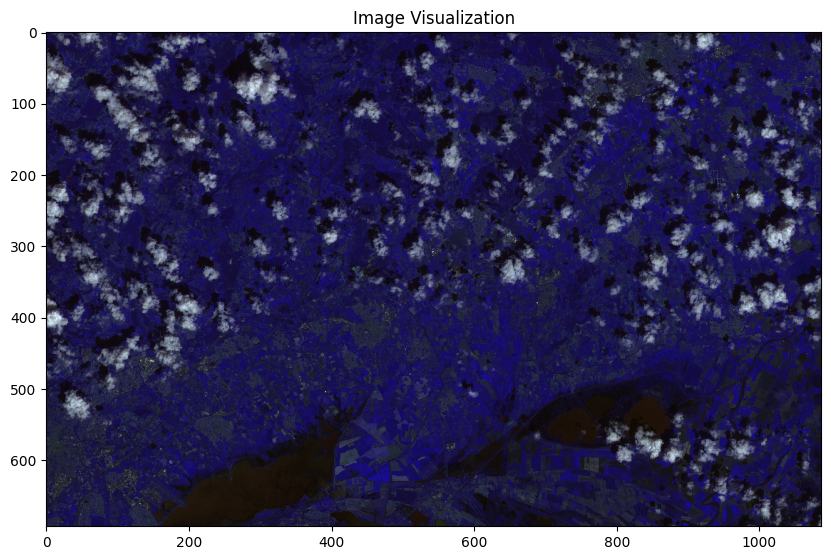

In [71]:
datacube = createDataCube()
result = datacube.download(format="GTIFF")

with BytesIO(result) as memfile:
    with rasterio.open(memfile) as src:
        RED = src.read(1)
        BLUE = src.read(2)
        NIR = src.read(3)

        # Stack bands and transpose to (height, width, channels)
        rgb = np.dstack((RED, BLUE, NIR))

# The result will be weird but it shows the result image with three bands
plt.figure(figsize=(10, 8))
plt.imshow(rgb)
plt.title("Image Visualization")
plt.show()